In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [4]:
df = pd.read_csv('../data/processed/churn_cleaned.csv')

print(df.shape)
print(df.dtypes)
print(df.head())

(10000, 15)
CreditScore             int64
Geography              object
Gender                  int64
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type              object
Point Earned            int64
dtype: object
   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France       0   42       2       0.00              1   
1          608     Spain       0   41       1   83807.86              1   
2          502    France       0   42       8  159660.80              3   
3          699    France       0   39       1       0.00              2   
4          850     Spain       0   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  Complain  \
0     

In [5]:
print(df['Exited'].value_counts())
print()
print(df['Exited'].value_counts(normalize=True).round(3))

Exited
0    7962
1    2038
Name: count, dtype: int64

Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


## Class Imbalance
- Dataset is imbalanced: 79.6% stayed, 20.4% churned
- Accuracy will be a misleading metric
- Will use F1-Score and Recall as primary evaluation metrics
- Will handle imbalance using SMOTE during model training

C:\Users\Parth_Bansal\AppData\Local\Temp\ipykernel_48840\1857449015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Exited', data=df, palette=['#2ecc71','#e74c3c'])


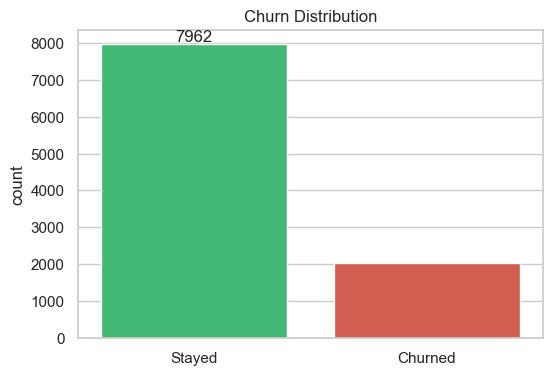

In [10]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Exited', data=df, palette=['#2ecc71','#e74c3c'])
ax.bar_label(ax.containers[0])
plt.title('Churn Distribution')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.xlabel('')
plt.show()

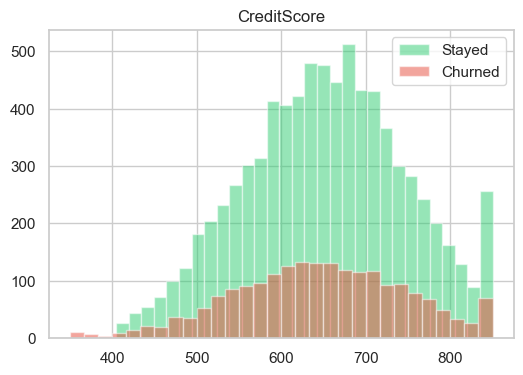

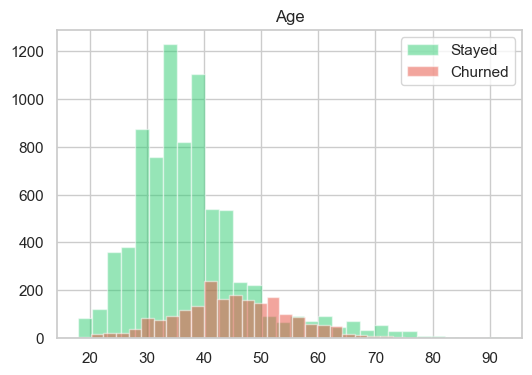

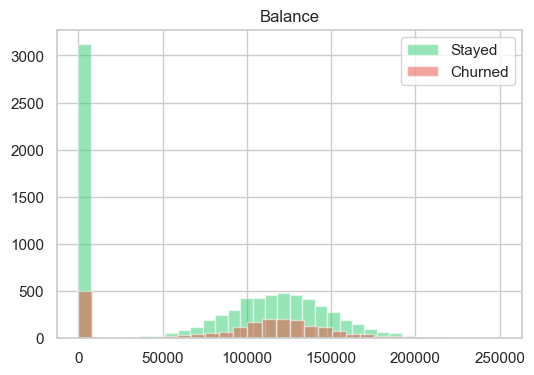

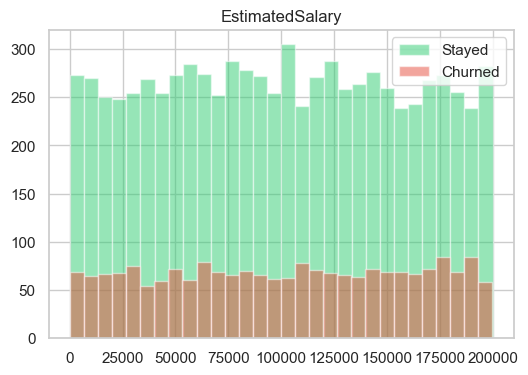

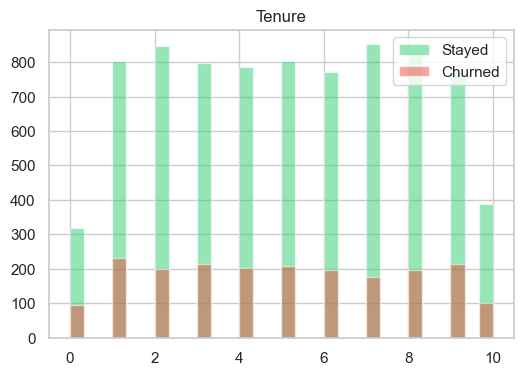

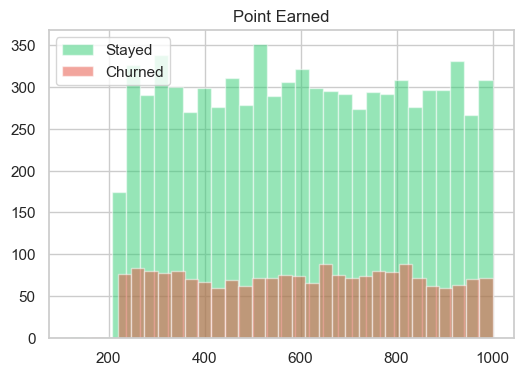

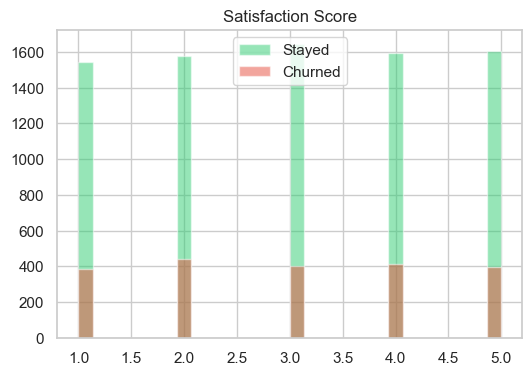

In [9]:
numerical = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 
             'Tenure', 'Point Earned', 'Satisfaction Score']

for col in numerical:
    plt.figure(figsize=(6,4))

    plt.hist(df[df['Exited']==0][col],
             alpha=0.5,
             label='Stayed',
             bins=30,
             color='#2ecc71')

    plt.hist(df[df['Exited']==1][col],
             alpha=0.5,
             label='Churned',
             bins=30,
             color='#e74c3c')

    plt.title(col)
    plt.legend()
    plt.show()


## EDA Insights : Numerical Features

### Key Findings

**Strong Predictors (Clear separation between Stayed vs Churned)**

**Age**
- Customers who stayed are concentrated in the 25–40 age range
- Customers who churned are concentrated in the 40–60 age range
- Older customers are significantly more likely to churn
- Action: Age will be a top feature in our model

**Balance**
- Large spike at zero balance : both stayed and churned customers have zero balance
- However, customers with balance between 100K–200K show higher churn proportion
- Will create a new feature: `IsZeroBalance` (1 if Balance == 0, else 0)
- Action: Balance + IsZeroBalance both will be used in model

---

**Weak Predictors (No clear separation)**

| Feature | Observation |
|---|---|
| CreditScore | Similar distribution for stayed and churned : weak signal |
| EstimatedSalary | Completely flat : salary has no impact on churn |
| Point Earned | No separation across point ranges : weak predictor |
| Tenure | Churn rate is consistent across all tenure years : weak signal |
| Satisfaction Score | Surprising - even score 1 and score 5 show same churn rate |

---

### Business Insight
- A customer being older (40+) with a non-zero balance is at higher risk of churning
- Satisfaction score alone is not a reliable churn indicator in this dataset
- Salary and loyalty points have no observable relationship with churn behavior

<Figure size 800x500 with 0 Axes>

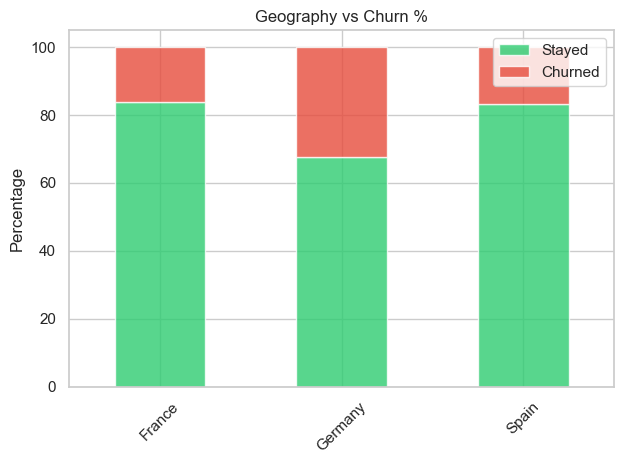

<Figure size 800x500 with 0 Axes>

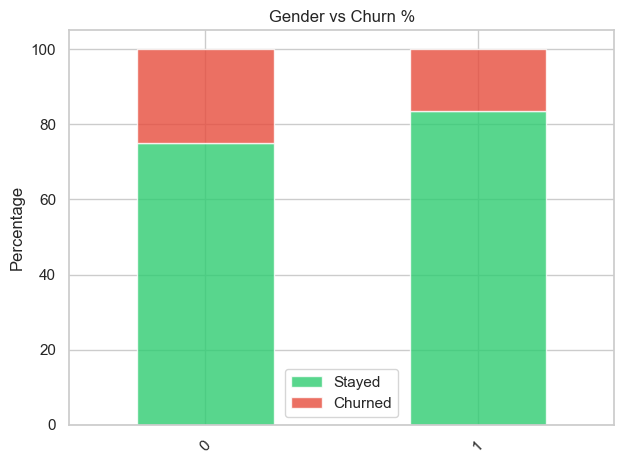

<Figure size 800x500 with 0 Axes>

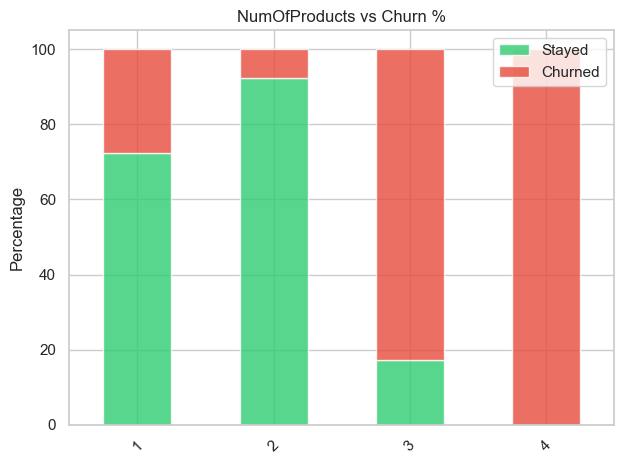

<Figure size 800x500 with 0 Axes>

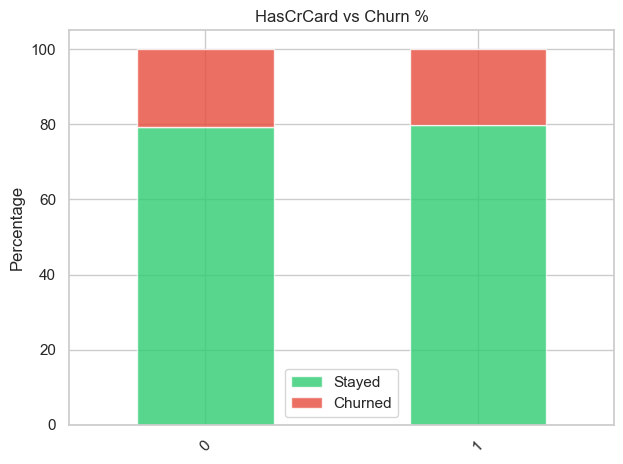

<Figure size 800x500 with 0 Axes>

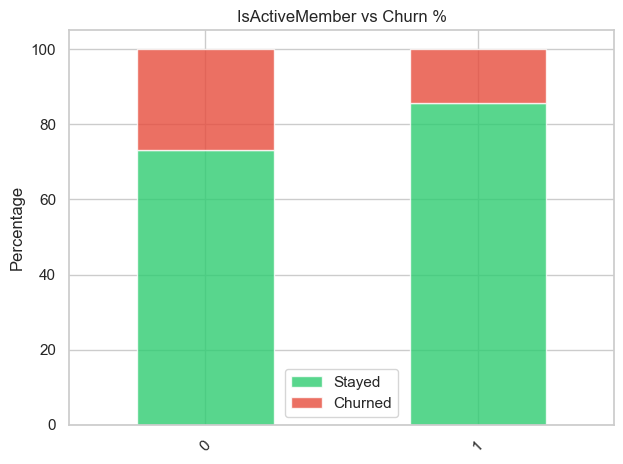

<Figure size 800x500 with 0 Axes>

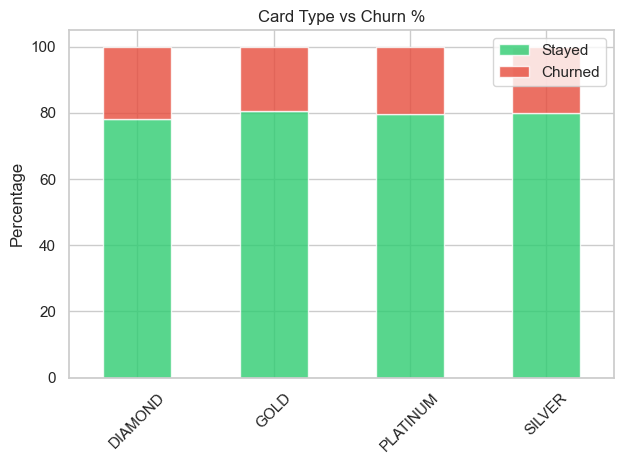

In [12]:
cat_cols = ['Geography', 'Gender', 'NumOfProducts',
            'HasCrCard', 'IsActiveMember', 'Card Type']

for col in cat_cols:

    plt.figure(figsize=(8,5))

    ct = pd.crosstab(df[col], df['Exited'], normalize='index') * 100

    ct = ct[[0, 1]]  # Stayed first, Churned second

    ct.plot(
        kind='bar',
        stacked=True,
        color=['#2ecc71', '#e74c3c'],
        alpha=0.8
    )

    plt.title(f'{col} vs Churn %')
    plt.xlabel('')
    plt.ylabel('Percentage')
    plt.legend(['Stayed', 'Churned'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## EDA Insights - Categorical Features

### Strong Predictors

**Geography**
- Germany has ~32% churn rate , almost double compared to France (~16%) and Spain (~17%)
- France and Spain behave similarly
- Germany customers are significantly higher risk
- Action: Geography will be an important feature : encode properly via OneHotEncoder in pipeline

**NumOfProducts**
- Products = 1: ~27% churn rate (moderate risk) 
- Products = 2: ~8% churn rate (most loyal segment)
- Products = 3: ~83% churn rate (almost all churned)
- Products = 4: ~100% churn rate (everyone left)
- This is the strongest categorical signal in the entire dataset
- Action: Top priority feature for the model

**IsActiveMember**
- Inactive members (0): ~27% churn rate
- Active members (1): ~15% churn rate
- Active engagement clearly reduces churn
- Action: Strong feature - keep as-is

**Gender**
- Female (0): ~25% churn rate
- Male (1): ~16% churn rate
- Females are more likely to churn (moderate signal)
- Action: Include in model (already encoded)

---

### Weak Predictors

| Feature | Observation |
|---|---|
| HasCrCard | Credit card holders and non-holders show same churn rate (no signal) |
| Card Type | Diamond, Gold, Platinum, Silver - all show ~20% churn (no difference) |

---

### Business Insights
- A German female customer with 3–4 products who is inactive is the highest risk profile
- Having a credit card or premium card type does not retain customers
- Active membership is a retention lever the bank can directly influence
- NumOfProducts = 2 is the sweet spot (these customers are most loyal)

---

### Full Feature Priority Summary

| Feature | Signal | Use in Model |
|---|---|---|
| NumOfProducts | ✅ Strongest | Yes |
| Geography | ✅ Strong | Yes (via pipeline) |
| Age | ✅ Strong | Yes |
| IsActiveMember | ✅ Strong | Yes |
| Gender | ⚠️ Moderate | Yes |
| Balance | ✅ Strong | Yes + IsZeroBalance feature |
| CreditScore | ❌ Weak | Include but low importance expected |
| Tenure | ❌ Weak | Include but low importance expected |
| EstimatedSalary | ❌ Weak | Can drop |
| Satisfaction Score | ❌ None | Can drop |
| Point Earned | ❌ Weak | Can drop |
| HasCrCard | ❌ None | Drop |
| Card Type | ❌ None | Drop |

In [17]:
# Geography
print(df.groupby('Geography')['Exited'].mean().round(3) * 100)

# NumOfProducts  
print(df.groupby('NumOfProducts')['Exited'].mean().round(3) * 100)

# Gender
print(df.groupby('Gender')['Exited'].mean().round(3) * 100)

# IsActiveMember
print(df.groupby('IsActiveMember')['Exited'].mean().round(3) * 100)

# HasCrCard
print(df.groupby('HasCrCard')['Exited'].mean().round(3) * 100)

# Card Type
print(df.groupby('Card Type')['Exited'].mean().round(3) * 100)

Geography
France     16.2
Germany    32.4
Spain      16.7
Name: Exited, dtype: float64
NumOfProducts
1     27.7
2      7.6
3     82.7
4    100.0
Name: Exited, dtype: float64
Gender
0    25.1
1    16.5
Name: Exited, dtype: float64
IsActiveMember
0    26.9
1    14.3
Name: Exited, dtype: float64
HasCrCard
0    20.8
1    20.2
Name: Exited, dtype: float64
Card Type
DIAMOND     21.8
GOLD        19.3
PLATINUM    20.4
SILVER      20.1
Name: Exited, dtype: float64


In [18]:
print(df.groupby('Complain')['Exited'].mean().round(3) * 100)

Complain
0     0.1
1    99.5
Name: Exited, dtype: float64


**Complain : Special Case (Data Leakage Risk)**
- Complain = 0: 0.1% churn
- Complain = 1: 99.5% churn
- Near-perfect predictor BUT likely data leakage
- Complain and churn are probably recorded simultaneously in this dataset
- Decision: Exclude from model - use as business insight only
- Business Recommendation: Any customer who raises a complaint must be 
  contacted within 24 hours - current data shows 99.5% of complainers leave

## EDA Insights - Categorical Features

### Strong Predictors

**Geography**
- France: 16.2% churn | Germany: 32.4% churn | Spain: 16.7% churn
- Germany churn rate is exactly 2x compared to France and Spain
- France and Spain behave almost identically can be treated as one group
- This suggests a Germany-specific operational or service issue worth investigating
- Action: Strong feature encode via OneHotEncoder in pipeline

**NumOfProducts**
- Products = 1: 27.7% churn (moderate risk)
- Products = 2: 7.6% churn (most loyal - sweet spot)
- Products = 3: 82.7% churn (critical risk)
- Products = 4: 100.0% churn (every single customer left)
- Pattern: Not a gradual increase this is a cliff after 2 products
- Customers with 3-4 products are likely over-sold or mis-sold products
- The bank's cross-selling strategy may be backfiring beyond 2 products
- Action: Strongest signal in dataset top priority feature

**IsActiveMember**
- Inactive (0): 26.9% churn
- Active (1): 14.3% churn
- Active members are nearly half as likely to churn
- Inactivity is an early warning sign the bank can monitor in real time
- Action: Strong feature + directly actionable retention lever for the bank

**Gender**
- Female (0): 25.1% churn
- Male (1): 16.5% churn
- Female customers churn at 1.5x the rate of male customers
- Gender-specific retention campaigns could be considered
- Action: Moderate-strong signal include in model

---

### Weak Predictors

| Feature | Churn Rate | Observation |
|---|---|---|
| HasCrCard = 0 | 20.8% | No credit card |
| HasCrCard = 1 | 20.2% | Has credit card |
| Observation | - | 0.6% difference - credit card has zero retention impact |
| Card Type: DIAMOND | 21.8% | Highest churn among card types |
| Card Type: GOLD | 19.3% | Lowest churn among card types |
| Card Type: PLATINUM | 20.4% | Similar to average |
| Card Type: SILVER | 20.1% | Similar to average |
| Observation | - | Max spread is only 2.5% card type is not a churn driver |

---

### Business Insights

- **Highest risk customer profile:** German female, inactive, with 3+ products
- **Lowest risk customer profile:** French or Spanish active male with exactly 2 products (7.6% churn)
- **Cross-selling backfires:** Customers with 3-4 products churn at 82-100% the bank is likely pushing too many products
- **Premium cards don't retain:** Diamond card holders (21.8%) churn more than Gold holders (19.3%) premium status alone is not a loyalty driver
- **Credit cards are irrelevant:** 0.6% difference makes HasCrCard practically useless as a predictor
- **Germany needs investigation:** 32.4% churn vs 16% elsewhere could indicate regional service gaps, competitor activity, or pricing issues

---

### Full Feature Priority Summary

| Feature | Churn Signal | Use in Model |
|---|---|---|
| NumOfProducts | ✅ Strongest (7.6% → 100%) | Yes |
| Geography | ✅ Strong (Germany 2x others) | Yes via pipeline |
| IsActiveMember | ✅ Strong (26.9% vs 14.3%) | Yes |
| Age | ✅ Strong (40–60 high risk) | Yes |
| Gender | ⚠️ Moderate (25.1% vs 16.5%) | Yes |
| Balance | ✅ Strong (100K–200K high risk) | Yes + IsZeroBalance feature |
| CreditScore | ❌ Weak | Include low importance expected |
| Tenure | ❌ Weak | Include low importance expected |
| Complain | ⚠️⚠️ Risky | May cause data leakage |
| EstimatedSalary | ❌ Weak | Drop |
| Satisfaction Score | ❌ None | Drop |
| Point Earned | ❌ Weak | Drop |
| HasCrCard | ❌ None (0.6% diff) | Drop |
| Card Type | ❌ None (2.5% spread) | Drop |